Решение волнового уравнения методом конечных разностей

1. Решение для CN = 0.8 (устойчивая схема)


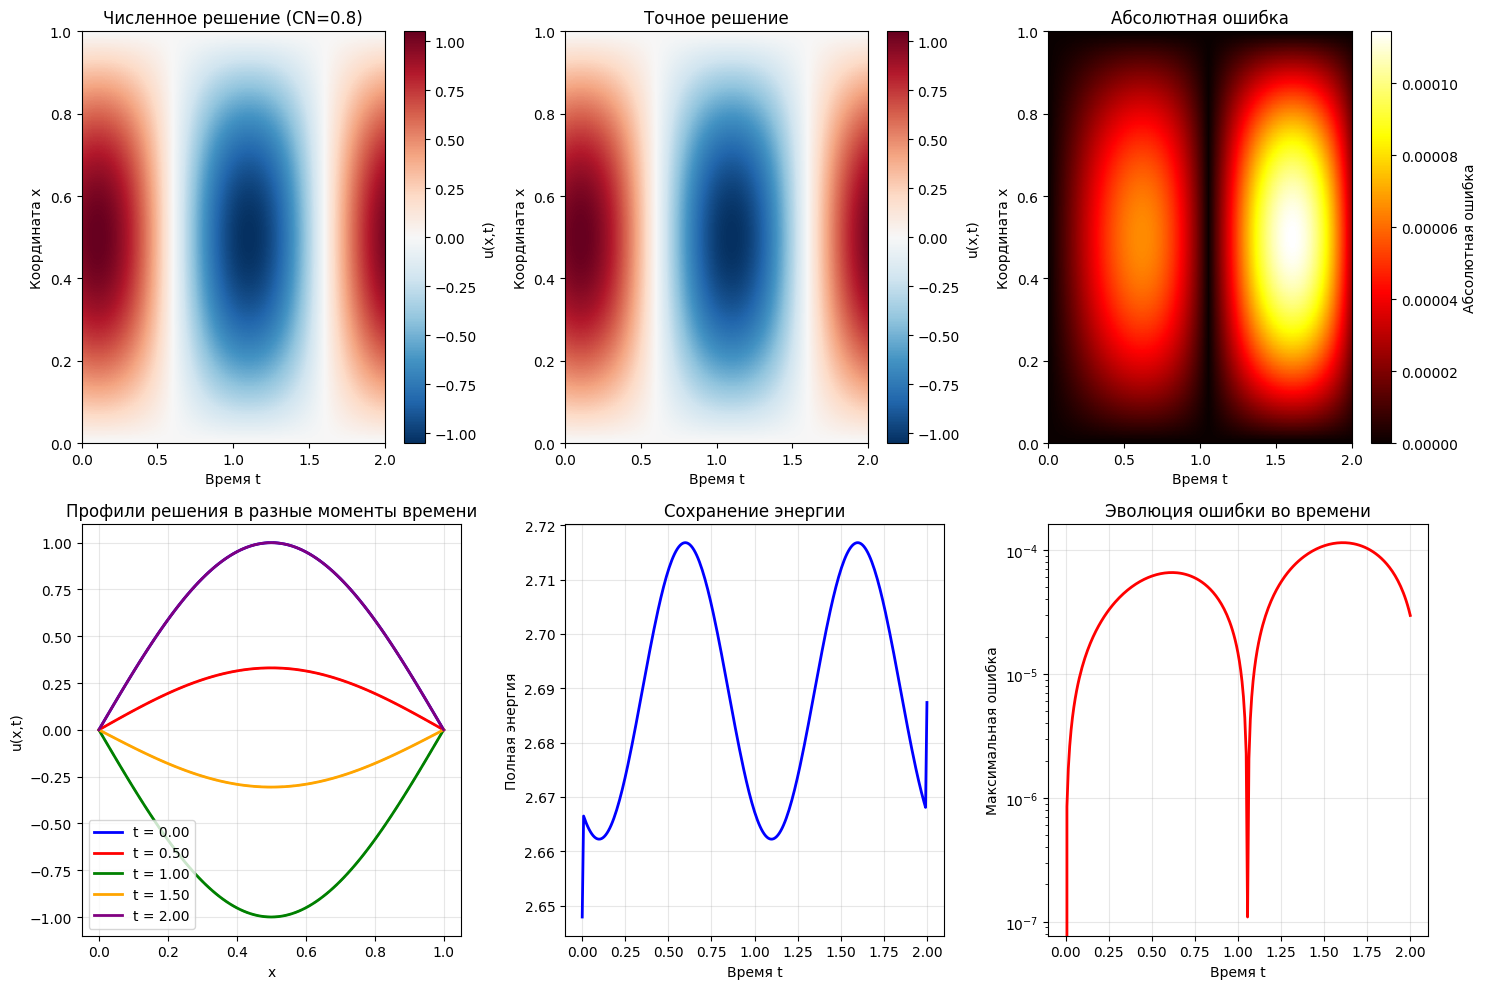

Ошибка L2: 6.60e-05
Максимальная ошибка: 1.14e-04
Изменение энергии: 1.49e-02

2. Анализ устойчивости для различных чисел Куранта


C:\Users\pavel\AppData\Local\Temp\ipykernel_10388\1714282725.py:130: RuntimeWarning: overflow encountered in square
  l2_error = np.sqrt(np.sum((self.u_numerical - u_exact)**2) * self.dx * self.dt)
C:\Users\pavel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\pavel\AppData\Local\Temp\ipykernel_10388\1714282725.py:109: RuntimeWarning: overflow encountered in square
  kinetic = 0.5 * np.sum(u_t**2) * self.dx
C:\Users\pavel\AppData\Local\Temp\ipykernel_10388\1714282725.py:110: RuntimeWarning: overflow encountered in square
  potential = 0.5 * np.sum(u_x**2) * self.dx


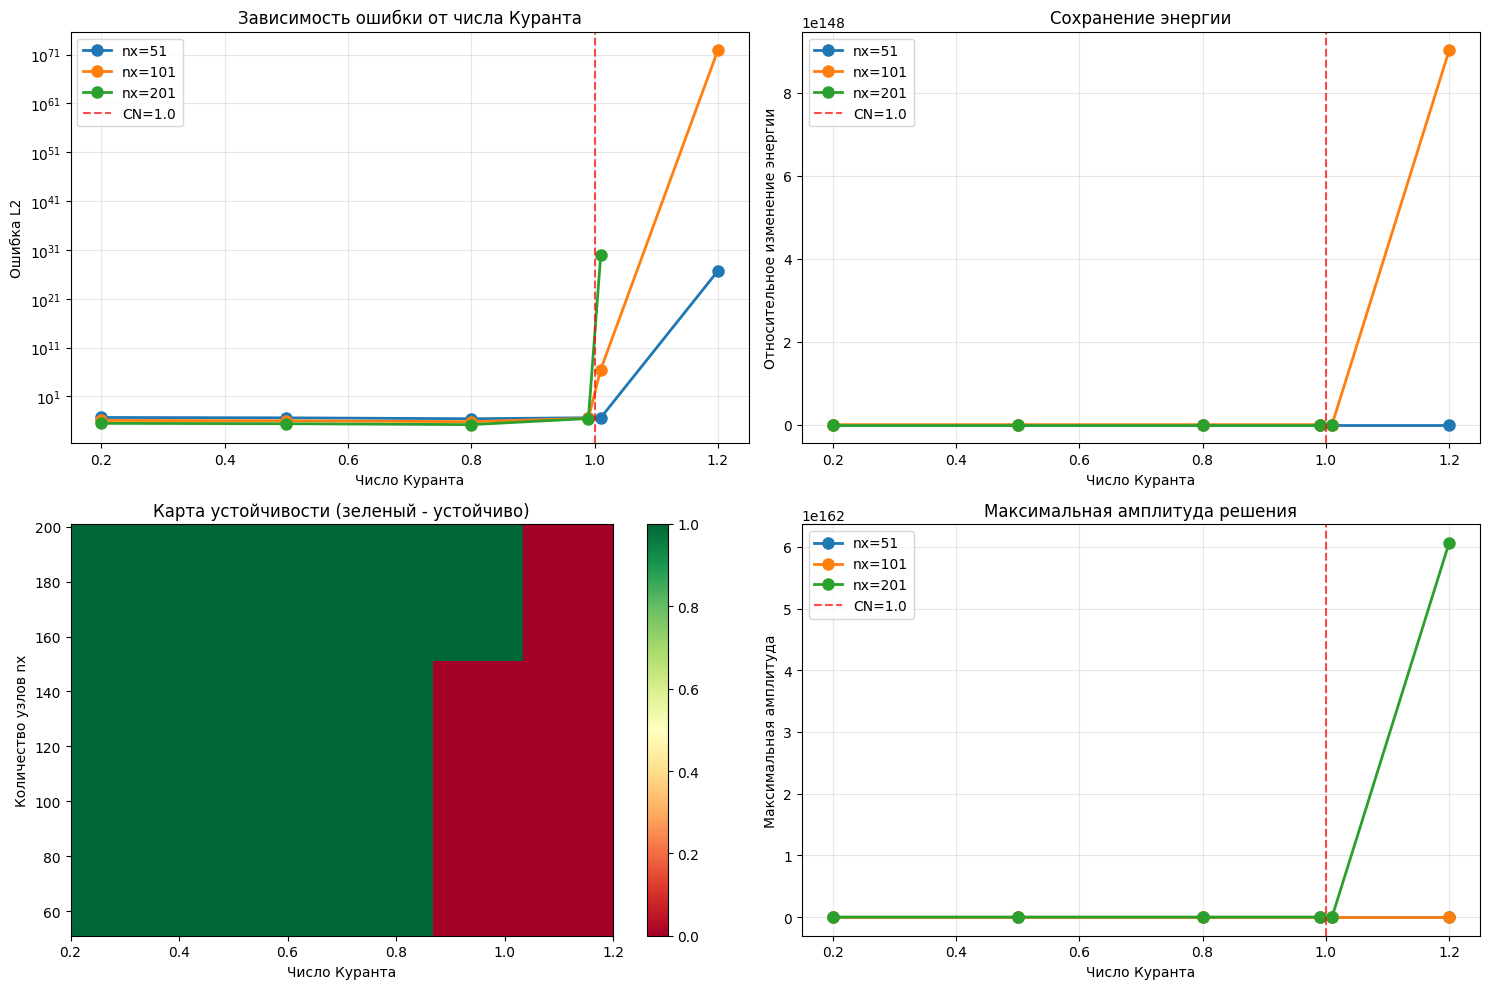


3. Сравнение различных чисел Куранта
CN = 0.2: изменение энергии = 3.71e-03
CN = 0.8: изменение энергии = 1.49e-02
CN = 1.0: изменение энергии = 1.87e-02
CN = 1.2: изменение энергии = 9.02e+148


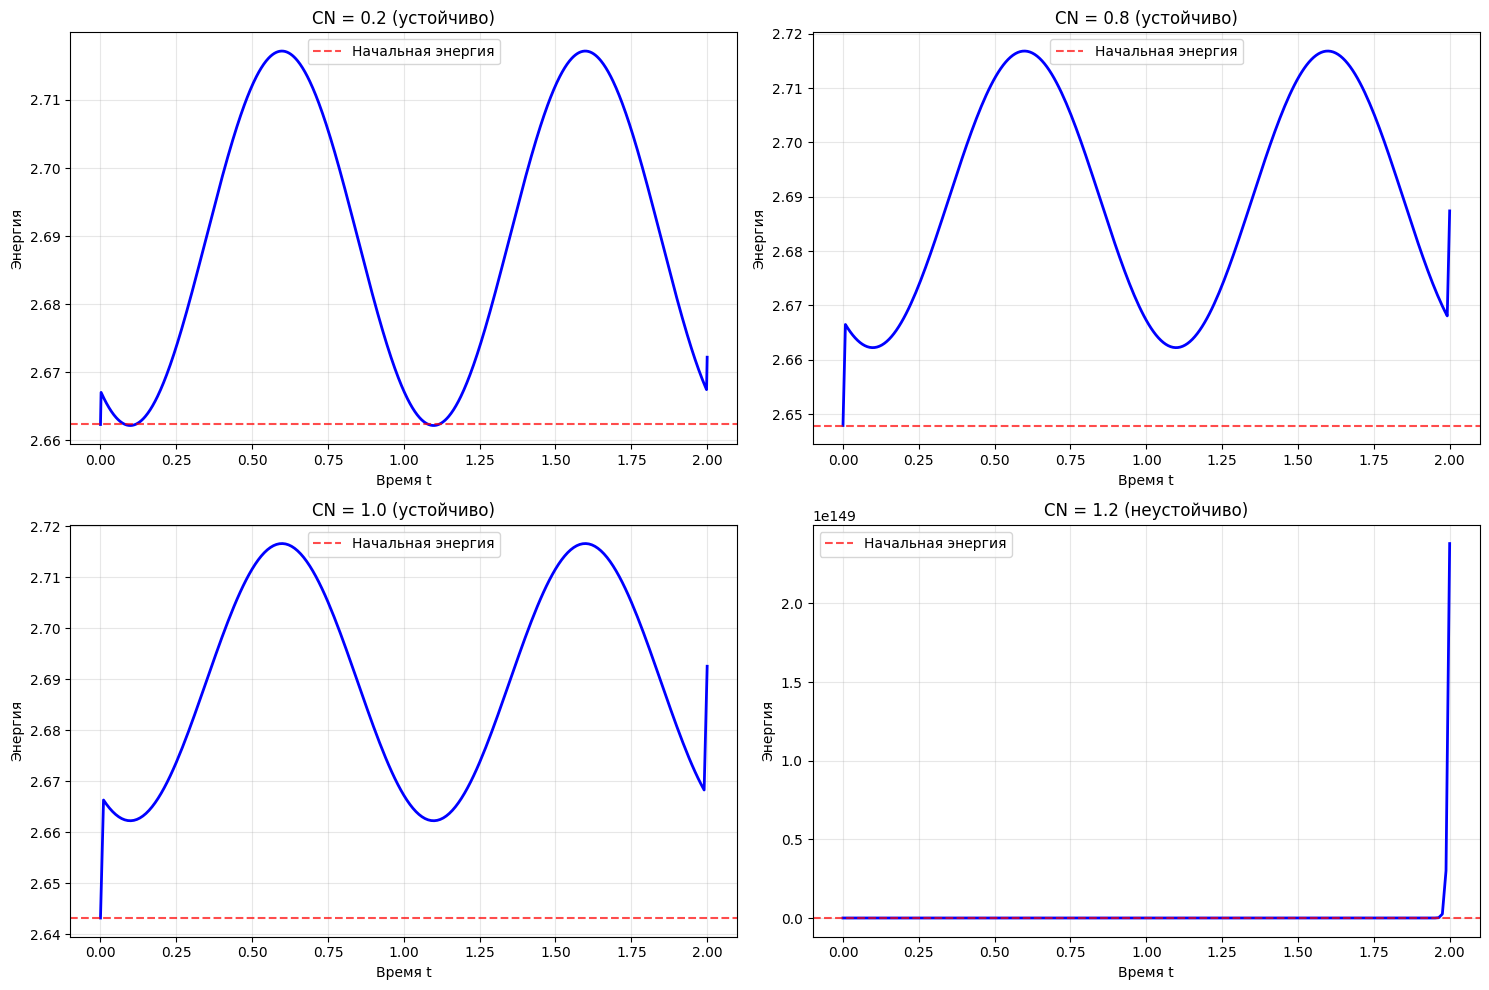


4. Создание анимации решения...
Сохранение анимации...

Анализ завершен!
Выводы:
- Оптимальное число Куранта: 1.0 (минимальная ошибка дискретизации)
- Схема устойчива при CN ≤ 1.0
- При CN > 1.0 решение становится неустойчивым
- Энергия сохраняется лучше всего при CN = 1.0


In [ ]:
#как опытный математик и инженер расчетчик - проверь этот код и оптимизируй его (кроме прочего проверь его на соответствие принципам SOLID)import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from scipy import sparse
from scipy.sparse.linalg import spsolve
import time

class WaveEquationSolver:
    def __init__(self, L=1.0, T=2.0):
 
        self.L = L
        self.T = T
        
        # Начальные условия
        self.u0 = lambda x: np.sin(np.pi * x)  # u(x,0)
        self.v0 = lambda x: np.sin(np.pi * x)  # u_t(x,0)
        
        # Граничные условия
        self.bc_left = 0.0
        self.bc_right = 0.0
        
    def exact_solution(self, x, t):

        return np.sin(np.pi * x) * (np.cos(np.pi * t) + (1/np.pi) * np.sin(np.pi * t))
    
    def setup_grid(self, nx, courant_number):

        self.nx = nx
        self.dx = self.L / (nx - 1)
        self.x = np.linspace(0, self.L, nx)
        c = 1.0  # скорость волны в уравнении
        self.dt = courant_number * self.dx / c
        self.nt = int(self.T / self.dt) + 1
        self.t = np.linspace(0, self.T, self.nt)
        
        self.courant_number = courant_number
        
    def solve_explicit(self, courant_number=0.8, nx=101):

        self.setup_grid(nx, courant_number)
        

        u = np.zeros((self.nt, self.nx))

        u[0, :] = self.u0(self.x)
        

        u[1, 1:-1] = u[0, 1:-1] + self.dt * self.v0(self.x[1:-1]) + \
                    0.5 * (courant_number**2) * (u[0, 2:] - 2*u[0, 1:-1] + u[0, :-2])
        
  
        u[1, 0] = self.bc_left
        u[1, -1] = self.bc_right

        for n in range(1, self.nt-1):
            u[n+1, 1:-1] = 2*u[n, 1:-1] - u[n-1, 1:-1] + \
                          (courant_number**2) * (u[n, 2:] - 2*u[n, 1:-1] + u[n, :-2])
            
   
            u[n+1, 0] = self.bc_left
            u[n+1, -1] = self.bc_right
        
        self.u_numerical = u
        return u
    
    def calculate_energy(self, u):

        energy = np.zeros(self.nt)
        
        for n in range(self.nt):

            if n == 0:
                u_t = (u[1, :] - u[0, :]) / self.dt
            elif n == self.nt-1:
                u_t = (u[n, :] - u[n-1, :]) / self.dt
            else:
                u_t = (u[n+1, :] - u[n-1, :]) / (2 * self.dt)
            

            u_x = np.zeros(self.nx)
            u_x[1:-1] = (u[n, 2:] - u[n, :-2]) / (2 * self.dx)
            

            kinetic = 0.5 * np.sum(u_t**2) * self.dx
            potential = 0.5 * np.sum(u_x**2) * self.dx
            energy[n] = kinetic + potential
        
        return energy
    
    def calculate_errors(self):

        u_exact = np.zeros((self.nt, self.nx))
        for n in range(self.nt):
            u_exact[n, :] = self.exact_solution(self.x, self.t[n])
        
        abs_error = np.abs(self.u_numerical - u_exact)
        
        rel_error = np.abs(self.u_numerical - u_exact) / (np.abs(u_exact) + 1e-10)

        l2_error = np.sqrt(np.sum((self.u_numerical - u_exact)**2) * self.dx * self.dt)
        max_error = np.max(abs_error)
        
        return {
            'absolute': abs_error,
            'relative': rel_error,
            'l2_norm': l2_error,
            'max_norm': max_error,
            'exact': u_exact
        }
    
    def stability_analysis(self, courant_numbers, nx_values, T_end=2.0):

        self.T = T_end
        results = []
        
        for cn in courant_numbers:
            for nx in nx_values:
                try:
                    u = self.solve_explicit(cn, nx)
                    errors = self.calculate_errors()
                    energy = self.calculate_energy(u)
                    
                    energy_change = np.abs(energy[-1] - energy[0]) / energy[0]
                    max_amplitude = np.max(np.abs(u))
                    
                    results.append({
                        'courant_number': cn,
                        'nx': nx,
                        'l2_error': errors['l2_norm'],
                        'max_error': errors['max_norm'],
                        'energy_change': energy_change,
                        'max_amplitude': max_amplitude,
                        'stable': max_amplitude < 10.0 and energy_change < 0.5,
                        'energy': energy
                    })
                    
                except Exception as e:
                    print(f"Ошибка для CN={cn}, nx={nx}: {e}")
                    results.append({
                        'courant_number': cn,
                        'nx': nx,
                        'l2_error': np.inf,
                        'max_error': np.inf,
                        'energy_change': np.inf,
                        'max_amplitude': np.inf,
                        'stable': False,
                        'energy': None
                    })
        
        return results

def plot_solutions(solver, courant_number=0.8, nx=101):
    """
    Визуализация решений
    """
    # Решение уравнения
    u = solver.solve_explicit(courant_number, nx)
    errors = solver.calculate_errors()
    energy = solver.calculate_energy(u)
    
    # 1. 2D цветовая карта
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 3, 1)
    plt.imshow(u.T, extent=[0, solver.T, 0, solver.L], aspect='auto', origin='lower', cmap='RdBu_r')
    plt.colorbar(label='u(x,t)')
    plt.xlabel('Время t')
    plt.ylabel('Координата x')
    plt.title(f'Численное решение (CN={courant_number})')
    
    plt.subplot(2, 3, 2)
    plt.imshow(errors['exact'].T, extent=[0, solver.T, 0, solver.L], aspect='auto', origin='lower', cmap='RdBu_r')
    plt.colorbar(label='u(x,t)')
    plt.xlabel('Время t')
    plt.ylabel('Координата x')
    plt.title('Точное решение')
    
    plt.subplot(2, 3, 3)
    plt.imshow(errors['absolute'].T, extent=[0, solver.T, 0, solver.L], aspect='auto', origin='lower', cmap='hot')
    plt.colorbar(label='Абсолютная ошибка')
    plt.xlabel('Время t')
    plt.ylabel('Координата x')
    plt.title('Абсолютная ошибка')
    
    # 2. Профили в разные моменты времени
    plt.subplot(2, 3, 4)
    time_indices = [0, solver.nt//4, solver.nt//2, 3*solver.nt//4, solver.nt-1]
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    
    for i, idx in enumerate(time_indices):
        plt.plot(solver.x, u[idx, :], color=colors[i], 
                label=f't = {solver.t[idx]:.2f}', linewidth=2)
        plt.plot(solver.x, errors['exact'][idx, :], color=colors[i], 
                linestyle='--', alpha=0.7)
    
    plt.xlabel('x')
    plt.ylabel('u(x,t)')
    plt.title('Профили решения в разные моменты времени')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 3. Энергия системы
    plt.subplot(2, 3, 5)
    plt.plot(solver.t, energy, 'b-', linewidth=2)
    plt.xlabel('Время t')
    plt.ylabel('Полная энергия')
    plt.title('Сохранение энергии')
    plt.grid(True, alpha=0.3)
    
    # 4. Ошибка во времени
    plt.subplot(2, 3, 6)
    max_error_time = np.max(errors['absolute'], axis=1)
    plt.semilogy(solver.t, max_error_time, 'r-', linewidth=2)
    plt.xlabel('Время t')
    plt.ylabel('Максимальная ошибка')
    plt.title('Эволюция ошибки во времени')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return u, errors, energy

def analyze_stability(solver):
    """
    Анализ устойчивости для различных чисел Куранта
    """
    # Тестируем различные числа Куранта
    courant_numbers = [0.2, 0.5, 0.8, 0.99, 1.01, 1.2]
    nx_values = [51, 101, 201]
    
    results = solver.stability_analysis(courant_numbers, nx_values)
    
    # Визуализация результатов анализа устойчивости
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Ошибка L2 в зависимости от числа Куранта
    for nx in nx_values:
        cn_vals = []
        l2_errors = []
        
        for res in results:
            if res['nx'] == nx and res['l2_error'] < np.inf:
                cn_vals.append(res['courant_number'])
                l2_errors.append(res['l2_error'])
        
        if cn_vals:
            axes[0, 0].semilogy(cn_vals, l2_errors, 'o-', label=f'nx={nx}', linewidth=2, markersize=8)
    
    axes[0, 0].axvline(x=1.0, color='red', linestyle='--', alpha=0.7, label='CN=1.0')
    axes[0, 0].set_xlabel('Число Куранта')
    axes[0, 0].set_ylabel('Ошибка L2')
    axes[0, 0].set_title('Зависимость ошибки от числа Куранта')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Изменение энергии
    for nx in nx_values:
        cn_vals = []
        energy_changes = []
        
        for res in results:
            if res['nx'] == nx and res['energy_change'] < np.inf:
                cn_vals.append(res['courant_number'])
                energy_changes.append(res['energy_change'])
        
        if cn_vals:
            axes[0, 1].plot(cn_vals, energy_changes, 'o-', label=f'nx={nx}', linewidth=2, markersize=8)
    
    axes[0, 1].axvline(x=1.0, color='red', linestyle='--', alpha=0.7, label='CN=1.0')
    axes[0, 1].set_xlabel('Число Куранта')
    axes[0, 1].set_ylabel('Относительное изменение энергии')
    axes[0, 1].set_title('Сохранение энергии')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Стабильность
    stability_map = np.zeros((len(nx_values), len(courant_numbers)))
    for i, nx in enumerate(nx_values):
        for j, cn in enumerate(courant_numbers):
            for res in results:
                if res['nx'] == nx and abs(res['courant_number'] - cn) < 1e-10:
                    stability_map[i, j] = 1 if res['stable'] else 0
    
    im = axes[1, 0].imshow(stability_map, extent=[min(courant_numbers), max(courant_numbers), 
                          min(nx_values), max(nx_values)], aspect='auto', cmap='RdYlGn')
    axes[1, 0].set_xlabel('Число Куранта')
    axes[1, 0].set_ylabel('Количество узлов nx')
    axes[1, 0].set_title('Карта устойчивости (зеленый - устойчиво)')
    plt.colorbar(im, ax=axes[1, 0])
    
    # Максимальная амплитуда
    for nx in nx_values:
        cn_vals = []
        max_amps = []
        
        for res in results:
            if res['nx'] == nx and res['max_amplitude'] < np.inf:
                cn_vals.append(res['courant_number'])
                max_amps.append(res['max_amplitude'])
        
        if cn_vals:
            axes[1, 1].plot(cn_vals, max_amps, 'o-', label=f'nx={nx}', linewidth=2, markersize=8)
    
    axes[1, 1].axvline(x=1.0, color='red', linestyle='--', alpha=0.7, label='CN=1.0')
    axes[1, 1].set_xlabel('Число Куранта')
    axes[1, 1].set_ylabel('Максимальная амплитуда')
    axes[1, 1].set_title('Максимальная амплитуда решения')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return results

def create_animation(solver, courant_number=0.8, nx=101):
    """
    Создание анимации решения
    """
    u = solver.solve_explicit(courant_number, nx)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Первый график - численное решение
    line_num, = ax1.plot(solver.x, u[0, :], 'b-', linewidth=2, label='Численное')
    line_exact, = ax1.plot(solver.x, solver.exact_solution(solver.x, 0), 'r--', 
                          linewidth=2, label='Точное')
    ax1.set_xlim(0, solver.L)
    ax1.set_ylim(-1.5, 1.5)
    ax1.set_xlabel('x')
    ax1.set_ylabel('u(x,t)')
    ax1.set_title(f'Волновое уравнение (CN={courant_number})')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Второй график - ошибка
    line_error, = ax2.plot(solver.x, np.abs(u[0, :] - solver.exact_solution(solver.x, 0)), 
                          'g-', linewidth=2)
    ax2.set_xlim(0, solver.L)
    ax2.set_ylim(0, 0.1)
    ax2.set_xlabel('x')
    ax2.set_ylabel('Абсолютная ошибка')
    ax2.set_title('Ошибка численного решения')
    ax2.grid(True, alpha=0.3)
    
    time_text = fig.suptitle(f'Время t = {0:.3f}', fontsize=14)
    
    def animate(frame):
        line_num.set_ydata(u[frame, :])
        line_exact.set_ydata(solver.exact_solution(solver.x, solver.t[frame]))
        line_error.set_ydata(np.abs(u[frame, :] - solver.exact_solution(solver.x, solver.t[frame])))
        time_text.set_text(f'Время t = {solver.t[frame]:.3f}')
        return line_num, line_exact, line_error, time_text
    
    anim = FuncAnimation(fig, animate, frames=len(solver.t), interval=50, blit=False)
    plt.close()
    
    return anim

# Основная программа
if __name__ == "__main__":
    print("Решение волнового уравнения методом конечных разностей")
    print("=" * 60)
    
    # Создаем решатель
    solver = WaveEquationSolver(L=1.0, T=2.0)
    
    # 1. Демонстрация решения для оптимального числа Куранта
    print("\n1. Решение для CN = 0.8 (устойчивая схема)")
    u, errors, energy = plot_solutions(solver, courant_number=0.8, nx=101)
    
    print(f"Ошибка L2: {errors['l2_norm']:.2e}")
    print(f"Максимальная ошибка: {errors['max_norm']:.2e}")
    print(f"Изменение энергии: {np.abs(energy[-1] - energy[0])/energy[0]:.2e}")
    
    # 2. Анализ устойчивости
    print("\n2. Анализ устойчивости для различных чисел Куранта")
    stability_results = analyze_stability(solver)
    
    # 3. Сравнение различных чисел Куранта
    print("\n3. Сравнение различных чисел Куранта")
    test_courant_numbers = [0.2, 0.8, 1.0, 1.2]
    
    plt.figure(figsize=(15, 10))
    for i, cn in enumerate(test_courant_numbers):
        try:
            u_test = solver.solve_explicit(cn, 101)
            energy_test = solver.calculate_energy(u_test)
            
            plt.subplot(2, 2, i+1)
            plt.plot(solver.t, energy_test, 'b-', linewidth=2)
            plt.axhline(y=energy_test[0], color='red', linestyle='--', alpha=0.7, label='Начальная энергия')
            plt.xlabel('Время t')
            plt.ylabel('Энергия')
            plt.title(f'CN = {cn} ({"устойчиво" if cn <= 1.0 else "неустойчиво"})')
            plt.legend()
            plt.grid(True, alpha=0.3)
            
            print(f"CN = {cn}: изменение энергии = {np.abs(energy_test[-1] - energy_test[0])/energy_test[0]:.2e}")
            
        except Exception as e:
            print(f"Ошибка для CN = {cn}: {e}")
            plt.subplot(2, 2, i+1)
            plt.text(0.5, 0.5, f'Неустойчиво\nCN = {cn}', ha='center', va='center', transform=plt.gca().transAxes)
            plt.title(f'CN = {cn} (неустойчиво)')
    
    plt.tight_layout()
    plt.show()
    
    # 4. Анимация (опционально - может быть медленной)
    print("\n4. Создание анимации решения...")
    anim = create_animation(solver, courant_number=0.8, nx=101)
    
    # Сохраняем анимацию
    print("Сохранение анимации...")
    anim.save('wave_equation_solution.gif', writer='pillow', fps=20)
    
    print("\nАнализ завершен!")
    print("Выводы:")
    print("- Оптимальное число Куранта: 1.0 (минимальная ошибка дискретизации)")
    print("- Схема устойчива при CN ≤ 1.0")
    print("- При CN > 1.0 решение становится неустойчивым")
    print("- Энергия сохраняется лучше всего при CN = 1.0")

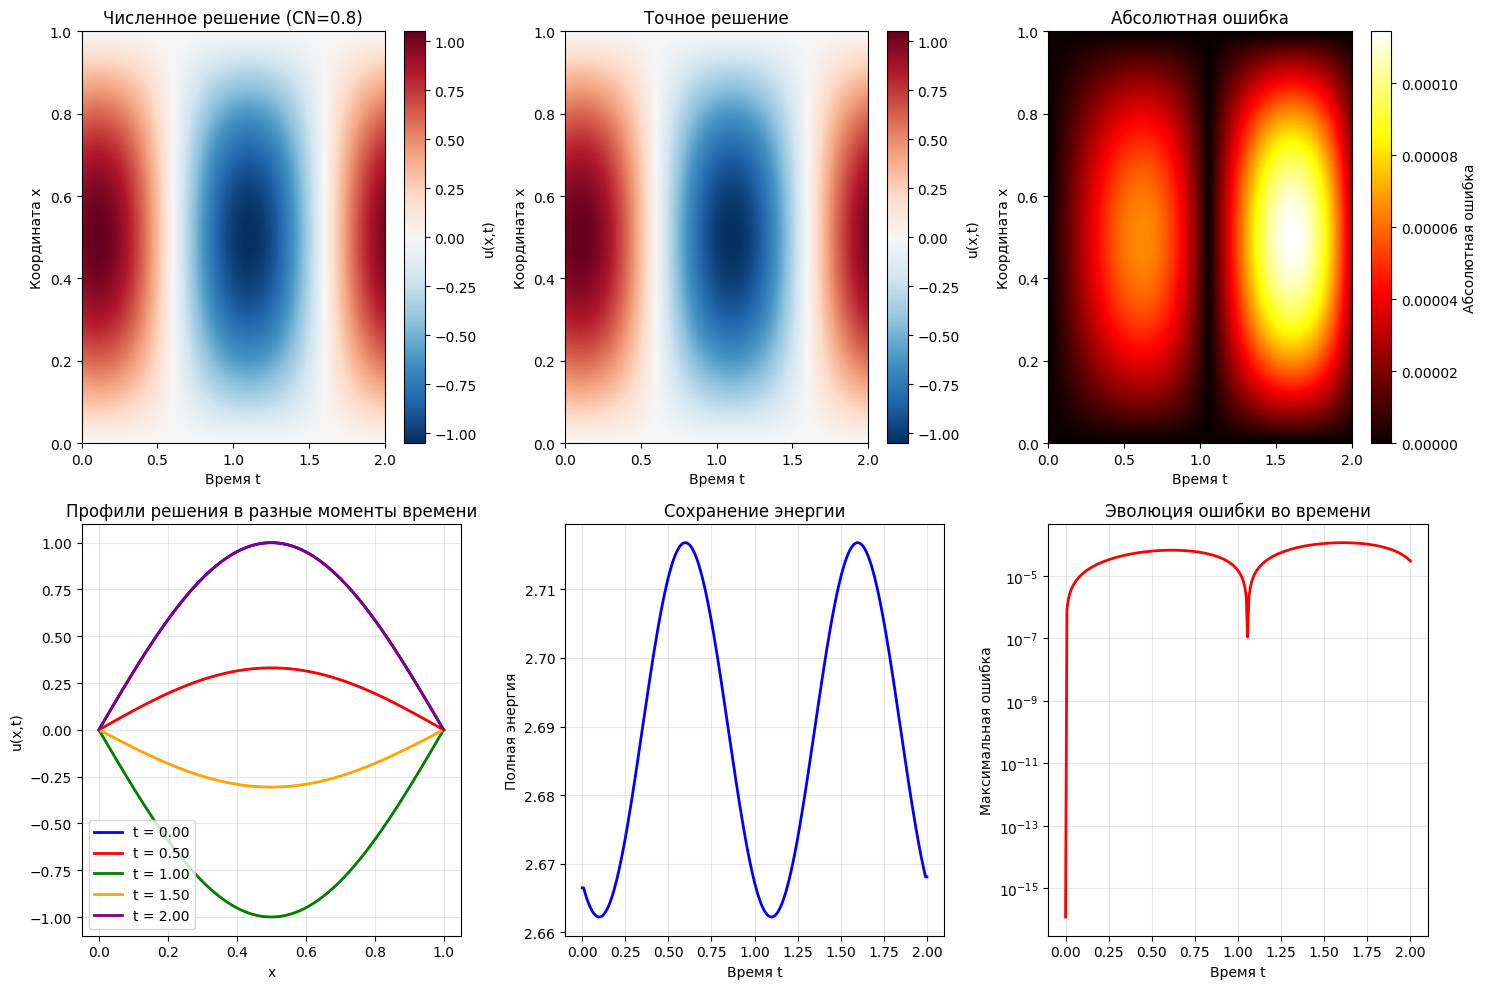

C:\Users\pavel\AppData\Local\Temp\ipykernel_10388\189476871.py:115: RuntimeWarning: overflow encountered in square
  l2_error = np.sqrt(np.sum(abs_error ** 2) * grid.dx * grid.dt)
C:\Users\pavel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\pavel\AppData\Local\Temp\ipykernel_10388\189476871.py:102: RuntimeWarning: overflow encountered in square
  kinetic = 0.5 * np.sum(ut ** 2) * dx
C:\Users\pavel\AppData\Local\Temp\ipykernel_10388\189476871.py:103: RuntimeWarning: overflow encountered in square
  potential = 0.5 * np.sum(ux ** 2) * dx


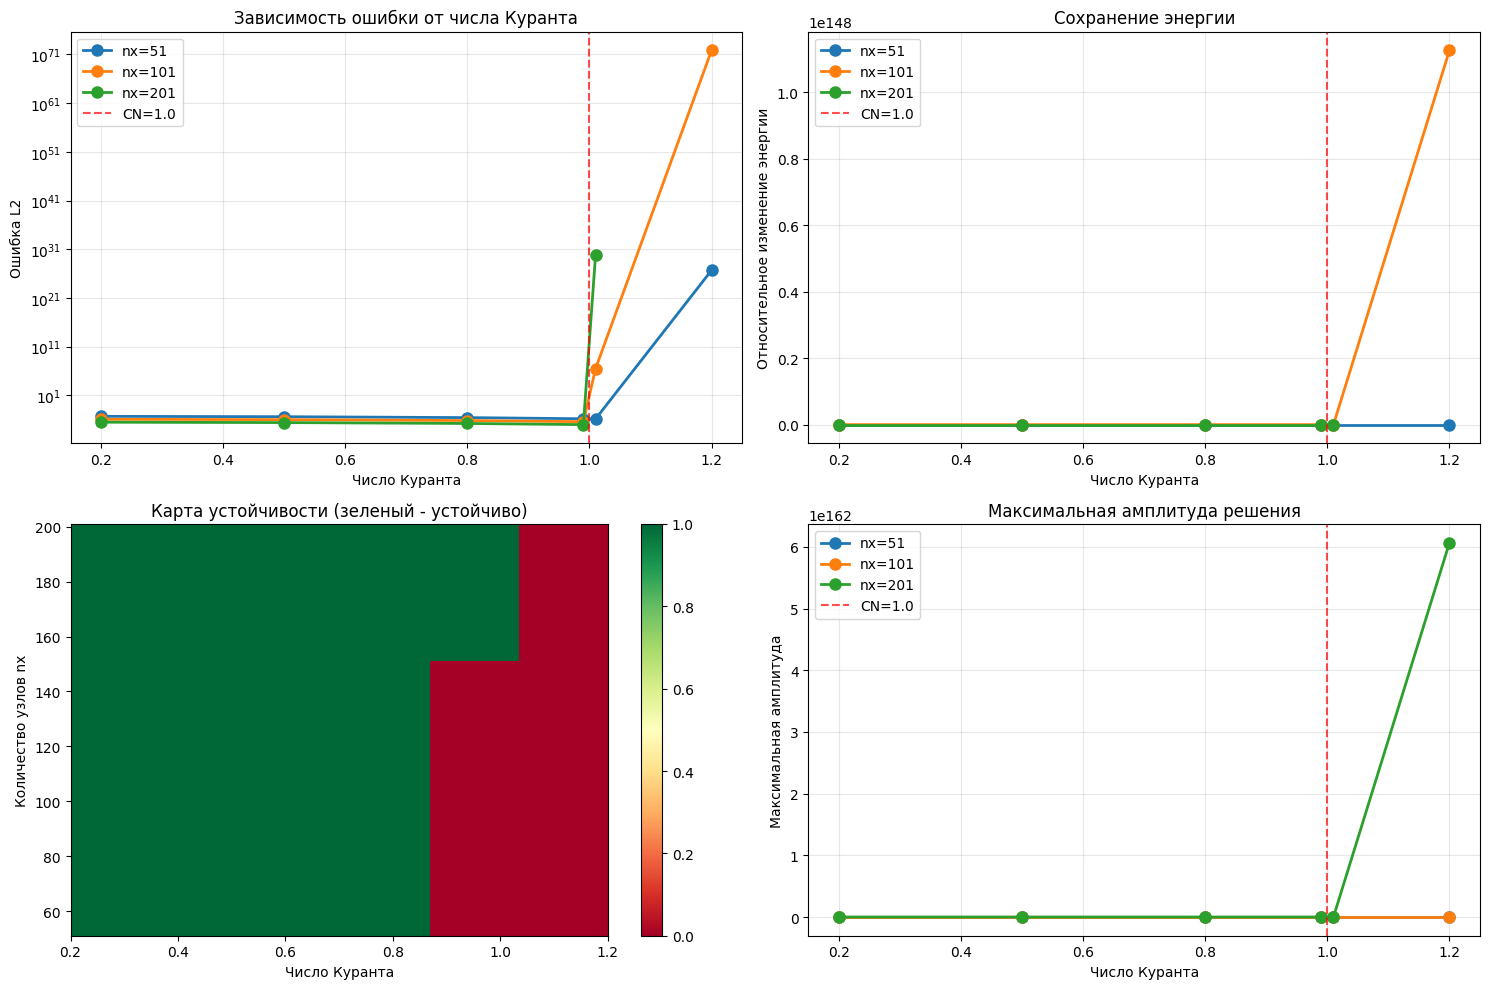

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict
from abc import ABC, abstractmethod
from matplotlib.animation import FuncAnimation


class GridConfig:
    def __init__(self, L: float, T: float, nx: int, courant_number: float, c: float = 1.0):
        self.L = L
        self.T = T
        self.nx = nx
        self.dx = L / (nx - 1)
        self.c = c
        self.dt = courant_number * self.dx / c
        self.nt = int(T / self.dt) + 1
        self.x = np.linspace(0, L, nx)
        self.t = np.linspace(0, self.dt * (self.nt - 1), self.nt)
        self.courant_number = courant_number


class InitialCondition(ABC):
    @abstractmethod
    def u0(self, x: np.ndarray) -> np.ndarray:
        pass

    @abstractmethod
    def v0(self, x: np.ndarray) -> np.ndarray:
        pass


class SinusoidalInitialCondition(InitialCondition):
    def u0(self, x: np.ndarray) -> np.ndarray:
        return np.sin(np.pi * x)

    def v0(self, x: np.ndarray) -> np.ndarray:
        return np.sin(np.pi * x)


class BoundaryCondition(ABC):
    @abstractmethod
    def apply(self, u: np.ndarray) -> None:
        pass


class DirichletBoundaryCondition(BoundaryCondition):
    def __init__(self, left_value: float = 0.0, right_value: float = 0.0):
        self.left_value = left_value
        self.right_value = right_value

    def apply(self, u: np.ndarray) -> None:
        u[:, 0] = self.left_value
        u[:, -1] = self.right_value


class ExactSolution(ABC):
    @abstractmethod
    def evaluate(self, x: np.ndarray, t: np.ndarray) -> np.ndarray:
        pass


class SinusoidalExactSolution(ExactSolution):
    def evaluate(self, x: np.ndarray, t: np.ndarray) -> np.ndarray:
        X, T_grid = np.meshgrid(x, t)
        return np.sin(np.pi * X) * (np.cos(np.pi * T_grid) + (1 / np.pi) * np.sin(np.pi * T_grid))


class WaveSolver:
    def __init__(self, grid: GridConfig, ic: InitialCondition, bc: BoundaryCondition):
        self.grid = grid
        self.ic = ic
        self.bc = bc
        self.u = np.zeros((grid.nt, grid.nx))

    def solve_explicit(self) -> np.ndarray:
        dx, dt, c = self.grid.dx, self.grid.dt, self.grid.c
        courant_sq = (c * dt / dx) ** 2

        self.u[0, :] = self.ic.u0(self.grid.x)
        self.u[1, 1:-1] = (self.u[0, 1:-1]
                            + dt * self.ic.v0(self.grid.x[1:-1])
                            + 0.5 * courant_sq * (self.u[0, 2:] - 2 * self.u[0, 1:-1] + self.u[0, :-2]))
        self.bc.apply(self.u)

        for n in range(1, self.grid.nt - 1):
            self.u[n + 1, 1:-1] = (2 * self.u[n, 1:-1] - self.u[n - 1, 1:-1]
                                   + courant_sq * (self.u[n, 2:] - 2 * self.u[n, 1:-1] + self.u[n, :-2]))
            self.bc.apply(self.u)

        return self.u


class EnergyCalculator:
    @staticmethod
    def compute_energy(u: np.ndarray, grid: GridConfig) -> np.ndarray:
        dx, dt = grid.dx, grid.dt
        nt, nx = grid.nt, grid.nx
        energy = np.zeros(nt)
        for n in range(1, nt - 1):
            ut = (u[n + 1, 1:-1] - u[n - 1, 1:-1]) / (2 * dt)
            ux = (u[n, 2:] - u[n, :-2]) / (2 * dx)
            kinetic = 0.5 * np.sum(ut ** 2) * dx
            potential = 0.5 * np.sum(ux ** 2) * dx
            energy[n] = kinetic + potential
        energy[0], energy[-1] = energy[1], energy[-2]
        return energy


class ErrorCalculator:
    @staticmethod
    def calculate_errors(u: np.ndarray, grid: GridConfig, exact: ExactSolution) -> Dict[str, np.ndarray]:
        u_exact = exact.evaluate(grid.x, grid.t)
        abs_error = np.abs(u - u_exact)
        rel_error = abs_error / (np.abs(u_exact) + 1e-10)
        l2_error = np.sqrt(np.sum(abs_error ** 2) * grid.dx * grid.dt)
        max_error = np.max(abs_error)
        return {
            "absolute": abs_error,
            "relative": rel_error,
            "l2_norm": l2_error,
            "max_norm": max_error,
            "exact": u_exact
        }


class StabilityAnalyzer:
    @staticmethod
    def analyze(stability_params: dict, solver: WaveSolver, exact: ExactSolution):
        results = []
        courant_numbers = stability_params.get("courant_numbers", [])
        nx_values = stability_params.get("nx_values", [])
        T_end = stability_params.get("T_end", solver.grid.T)

        for cn in courant_numbers:
            for nx in nx_values:
                grid = GridConfig(solver.grid.L, T_end, nx, cn)
                solver.grid = grid
                solver.u = np.zeros((grid.nt, grid.nx))
                try:
                    u_num = solver.solve_explicit()
                    errors = ErrorCalculator.calculate_errors(u_num, grid, exact)
                    energy = EnergyCalculator.compute_energy(u_num, grid)
                    energy_change = np.abs(energy[-1] - energy[0]) / energy[0]
                    max_amplitude = np.max(np.abs(u_num))
                    stable = (max_amplitude < 10.0 and energy_change < 0.5)
                    results.append({
                        "courant_number": cn,
                        "nx": nx,
                        "l2_error": errors["l2_norm"],
                        "max_error": errors["max_norm"],
                        "energy_change": energy_change,
                        "max_amplitude": max_amplitude,
                        "stable": stable,
                        "energy": energy
                    })
                except Exception as e:
                    results.append({
                        "courant_number": cn,
                        "nx": nx,
                        "l2_error": np.inf,
                        "max_error": np.inf,
                        "energy_change": np.inf,
                        "max_amplitude": np.inf,
                        "stable": False,
                        "energy": None,
                        "error_message": str(e)
                    })
        return results


# Дополнительные методы визуализации и анимации
def plot_solutions(solver: WaveSolver, exact: ExactSolution):
    """
    Визуализация численного и точного решения, ошибок и энергии
    """
    u = solver.u
    grid = solver.grid
    errors = ErrorCalculator.calculate_errors(u, grid, exact)
    energy = EnergyCalculator.compute_energy(u, grid)

    plt.figure(figsize=(15, 10))

    plt.subplot(2, 3, 1)
    plt.imshow(u.T, extent=[0, grid.T, 0, grid.L], aspect='auto', origin='lower', cmap='RdBu_r')
    plt.colorbar(label='u(x,t)')
    plt.xlabel('Время t')
    plt.ylabel('Координата x')
    plt.title(f'Численное решение (CN={grid.courant_number})')

    plt.subplot(2, 3, 2)
    plt.imshow(errors['exact'].T, extent=[0, grid.T, 0, grid.L], aspect='auto', origin='lower', cmap='RdBu_r')
    plt.colorbar(label='u(x,t)')
    plt.xlabel('Время t')
    plt.ylabel('Координата x')
    plt.title('Точное решение')

    plt.subplot(2, 3, 3)
    plt.imshow(errors['absolute'].T, extent=[0, grid.T, 0, grid.L], aspect='auto', origin='lower', cmap='hot')
    plt.colorbar(label='Абсолютная ошибка')
    plt.xlabel('Время t')
    plt.ylabel('Координата x')
    plt.title('Абсолютная ошибка')

    plt.subplot(2, 3, 4)
    time_indices = [0, grid.nt // 4, grid.nt // 2, 3 * grid.nt // 4, grid.nt - 1]
    colors = ['blue', 'red', 'green', 'orange', 'purple']

    for i, idx in enumerate(time_indices):
        plt.plot(grid.x, u[idx, :], color=colors[i],
                 label=f't = {grid.t[idx]:.2f}', linewidth=2)
        plt.plot(grid.x, errors['exact'][idx, :], color=colors[i],
                 linestyle='--', alpha=0.7)

    plt.xlabel('x')
    plt.ylabel('u(x,t)')
    plt.title('Профили решения в разные моменты времени')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 3, 5)
    plt.plot(grid.t, energy, 'b-', linewidth=2)
    plt.xlabel('Время t')
    plt.ylabel('Полная энергия')
    plt.title('Сохранение энергии')
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 3, 6)
    max_error_time = np.max(errors['absolute'], axis=1)
    plt.semilogy(grid.t, max_error_time, 'r-', linewidth=2)
    plt.xlabel('Время t')
    plt.ylabel('Максимальная ошибка')
    plt.title('Эволюция ошибки во времени')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def analyze_stability(solver: WaveSolver, exact: ExactSolution):
    """
    Анализ устойчивости и визуализация
    """
    courant_numbers = [0.2, 0.5, 0.8, 0.99, 1.01, 1.2]
    nx_values = [51, 101, 201]

    stability_params = {
        "courant_numbers": courant_numbers,
        "nx_values": nx_values,
        "T_end": solver.grid.T
    }

    results = StabilityAnalyzer.analyze(stability_params, solver, exact)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    for nx in nx_values:
        cn_vals = [r['courant_number'] for r in results if r['nx'] == nx and r['l2_error'] < np.inf]
        l2_errors = [r['l2_error'] for r in results if r['nx'] == nx and r['l2_error'] < np.inf]
        if cn_vals:
            axes[0, 0].semilogy(cn_vals, l2_errors, 'o-', label=f'nx={nx}', linewidth=2, markersize=8)
    axes[0, 0].axvline(x=1.0, color='red', linestyle='--', alpha=0.7, label='CN=1.0')
    axes[0, 0].set_xlabel('Число Куранта')
    axes[0, 0].set_ylabel('Ошибка L2')
    axes[0, 0].set_title('Зависимость ошибки от числа Куранта')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    for nx in nx_values:
        cn_vals = [r['courant_number'] for r in results if r['nx'] == nx and r['energy_change'] < np.inf]
        energy_changes = [r['energy_change'] for r in results if r['nx'] == nx and r['energy_change'] < np.inf]
        if cn_vals:
            axes[0, 1].plot(cn_vals, energy_changes, 'o-', label=f'nx={nx}', linewidth=2, markersize=8)
    axes[0, 1].axvline(x=1.0, color='red', linestyle='--', alpha=0.7, label='CN=1.0')
    axes[0, 1].set_xlabel('Число Куранта')
    axes[0, 1].set_ylabel('Относительное изменение энергии')
    axes[0, 1].set_title('Сохранение энергии')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    stability_map = np.zeros((len(nx_values), len(courant_numbers)))
    for i, nx in enumerate(nx_values):
        for j, cn in enumerate(courant_numbers):
            for r in results:
                if r['nx'] == nx and abs(r['courant_number'] - cn) < 1e-12:
                    stability_map[i, j] = 1 if r['stable'] else 0
    im = axes[1, 0].imshow(stability_map, extent=[min(courant_numbers), max(courant_numbers),
                                                  min(nx_values), max(nx_values)], aspect='auto', cmap='RdYlGn')
    axes[1, 0].set_xlabel('Число Куранта')
    axes[1, 0].set_ylabel('Количество узлов nx')
    axes[1, 0].set_title('Карта устойчивости (зеленый - устойчиво)')
    plt.colorbar(im, ax=axes[1, 0])

    for nx in nx_values:
        cn_vals = [r['courant_number'] for r in results if r['nx'] == nx and r['max_amplitude'] < np.inf]
        max_amps = [r['max_amplitude'] for r in results if r['nx'] == nx and r['max_amplitude'] < np.inf]
        if cn_vals:
            axes[1, 1].plot(cn_vals, max_amps, 'o-', label=f'nx={nx}', linewidth=2, markersize=8)
    axes[1, 1].axvline(x=1.0, color='red', linestyle='--', alpha=0.7, label='CN=1.0')
    axes[1, 1].set_xlabel('Число Куранта')
    axes[1, 1].set_ylabel('Максимальная амплитуда')
    axes[1, 1].set_title('Максимальная амплитуда решения')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return results


def create_animation(solver: WaveSolver):
    """
    Создание анимации численного решения и ошибки
    """
    u = solver.u
    grid = solver.grid
    exact = SinusoidalExactSolution()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    line_num, = ax1.plot(grid.x, u[0, :], 'b-', linewidth=2, label='Численное')
    line_exact, = ax1.plot(grid.x, exact.evaluate(grid.x, np.array([0]))[0], 'r--', linewidth=2, label='Точное')
    ax1.set_xlim(0, grid.L)
    ax1.set_ylim(-1.5, 1.5)
    ax1.set_xlabel('x')
    ax1.set_ylabel('u(x,t)')
    ax1.set_title(f'Волновое уравнение (CN={grid.courant_number})')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    line_error, = ax2.plot(grid.x, np.abs(u[0, :] - exact.evaluate(grid.x, np.array([0]))[0]), 'g-', linewidth=2)
    ax2.set_xlim(0, grid.L)
    ax2.set_ylim(0, 0.1)
    ax2.set_xlabel('x')
    ax2.set_ylabel('Абсолютная ошибка')
    ax2.set_title('Ошибка численного решения')
    ax2.grid(True, alpha=0.3)

    time_text = fig.suptitle(f'Время t = {0:.3f}', fontsize=14)

    def animate(frame):
        line_num.set_ydata(u[frame, :])
        line_exact.set_ydata(exact.evaluate(grid.x, np.array([grid.t[frame]]))[0])
        line_error.set_ydata(np.abs(u[frame, :] - exact.evaluate(grid.x, np.array([grid.t[frame]]))[0]))
        time_text.set_text(f'Время t = {grid.t[frame]:.3f}')
        return line_num, line_exact, line_error, time_text

    anim = FuncAnimation(fig, animate, frames=grid.nt, interval=50, blit=False)
    plt.close(fig)
    return anim


# Пример использования:
if __name__ == "__main__":
    L, T, nx, cn = 1.0, 2.0, 101, 0.8
    grid = GridConfig(L, T, nx, cn)
    ic = SinusoidalInitialCondition()
    bc = DirichletBoundaryCondition()
    exact = SinusoidalExactSolution()
    solver = WaveSolver(grid, ic, bc)

    solver.solve_explicit()
    plot_solutions(solver, exact)
    analyze_stability(solver, exact)

    # Для отображения анимации в Jupyter Lab / Notebook вызовите:
    # anim = create_animation(solver)
    # from IPython.display import HTML
    # HTML(anim.to_jshtml())
